CARGAMOS LIBRERIAS

In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



Descargamos DS desde Kaggle mediante Python

In [ ]:
# Descarga la última versión del dataset
path = kagglehub.dataset_download("enzoschitini/brazilian-e-commerce-public-dataset-by-olist")

print("La ruta de tus archivos es:", path)

Movemos el archivo de la caché a la carpeta Proyecto Final

In [ ]:
import shutil

# 1. Definimos las rutas. 
# Usamos 'r' al inicio (raw string) para evitar que las barras invertidas (\) causen errores en Windows.
ruta_origen = r"C:\Users\azqae\.cache\kagglehub\datasets\enzoschitini\brazilian-e-commerce-public-dataset-by-olist\versions\1"

# 2. Definimos el destino. 
# Nota: Agregué "\dataset_olist" al final para que los archivos no se desparramen sueltos en tu carpeta PF.
ruta_destino = r"C:\Users\azqae\Documents\Proyectos_Alejandro\PF\dataset_olist"

# 3. Copiamos la carpeta completa
try:
    # dirs_exist_ok=True permite que, si la carpeta ya existe, los archivos se peguen dentro sin dar error (Python 3.8+)
    shutil.copytree(ruta_origen, ruta_destino, dirs_exist_ok=True)
    print("¡Dataset copiado con éxito a tu carpeta de proyecto!")
except Exception as e:
    print(f"Ocurrió un error: {e}")

Con el archivo en carpeta destino, se realiza la carga CSV mediante Pandas y se realiza una exploración
de la informacion en columnas

In [2]:
DS_olist = pd.read_csv(r"C:\Users\azqae\Documents\Proyectos_Alejandro\PF\dataset_olist\Brazilian E-Commerce Public Dataset by Olist.csv")
print(DS_olist.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Unnamed: 0                     113390 non-null  int64  
 1   order_id                       113390 non-null  object 
 2   order_item_id                  113390 non-null  int64  
 3   customer_id                    113390 non-null  object 
 4   customer_unique_id             113390 non-null  object 
 5   customer_zip_code_prefix       113390 non-null  int64  
 6   customer_city                  113390 non-null  object 
 7   customer_state                 113390 non-null  object 
 8   product_id                     113390 non-null  object 
 9   product_category_name          113390 non-null  object 
 10  product_name_lenght            113390 non-null  float64
 11  product_description_lenght     113390 non-null  float64
 12  product_photos_qty            

Despues de la exploración de columnas totales, con base a las preguntas de negocio que se responderán
definimos las columnas a trabajar, verificamos nulos y uso de RAM

In [3]:
# Definimos la lista de las columnas estrictamente necesarias
columnas_utiles = [
    'order_id', 'order_item_id', 'customer_id', 'customer_unique_id', 
    'customer_city', 'customer_state', 'product_id', 'product_category_name',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'price', 'freight_value', 'payment_value', 'payment_type', 'payment_installments',
    'order_purchase_timestamp', 'order_status'
]

# Sobrescribimos el DataFrame quedándonos solo con las útiles (eliminando el resto)
DS_olist = DS_olist[columnas_utiles]

# Prints de confirmación y estado de la memoria
print(f"¡Columnas innecesarias eliminadas! Nos quedamos con {DS_olist.shape[1]} columnas clave.")
print("-" * 50)

# Verificamos la información del DataFrame (tipos de datos, nulos y uso de RAM)
DS_olist.info()

¡Columnas innecesarias eliminadas! Nos quedamos con 19 columnas clave.
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  113390 non-null  object 
 1   order_item_id             113390 non-null  int64  
 2   customer_id               113390 non-null  object 
 3   customer_unique_id        113390 non-null  object 
 4   customer_city             113390 non-null  object 
 5   customer_state            113390 non-null  object 
 6   product_id                113390 non-null  object 
 7   product_category_name     113390 non-null  object 
 8   product_weight_g          113390 non-null  float64
 9   product_length_cm         113390 non-null  float64
 10  product_height_cm         113390 non-null  float64
 11  product_width_cm          113390 n

Cambiamos el nombre de inglés a español para identificar fluidamente las columnas

In [4]:
# Diccionario con el mapeo exacto de los nombres: 'original': 'nuevo_nombre'
diccionario_renombrado = {
    'order_id': 'id_orden',
    'order_item_id': 'id_item_orden',
    'customer_id': 'id_cliente_orden',
    'customer_unique_id': 'id_cliente_unico',
    'customer_city': 'ciudad_cliente',
    'customer_state': 'estado_cliente',
    'product_id': 'id_producto',
    'product_category_name': 'categoria_producto',
    'product_weight_g': 'peso_g',
    'product_length_cm': 'longitud_cm',
    'product_height_cm': 'altura_cm',
    'product_width_cm': 'ancho_cm',
    'price': 'precio_producto',
    'freight_value': 'valor_flete',
    'payment_value': 'valor_pago_total',
    'payment_type': 'tipo_pago',
    'payment_installments': 'cuotas_pago',
    'order_purchase_timestamp': 'fecha_compra',
    'order_status': 'estado_orden'
}

# Aplicamos el cambio de nombre directamente sobre el DataFrame
DS_olist.rename(columns=diccionario_renombrado, inplace=True)

# Prints de confirmación visual
print("¡Columnas renombradas al español con éxito!")
print("-" * 50)
print(DS_olist.columns.tolist())

# Te muestro las primeras 3 filas para que veas cómo luce tu tabla ahora
display(DS_olist.info())

¡Columnas renombradas al español con éxito!
--------------------------------------------------
['id_orden', 'id_item_orden', 'id_cliente_orden', 'id_cliente_unico', 'ciudad_cliente', 'estado_cliente', 'id_producto', 'categoria_producto', 'peso_g', 'longitud_cm', 'altura_cm', 'ancho_cm', 'precio_producto', 'valor_flete', 'valor_pago_total', 'tipo_pago', 'cuotas_pago', 'fecha_compra', 'estado_orden']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id_orden            113390 non-null  object 
 1   id_item_orden       113390 non-null  int64  
 2   id_cliente_orden    113390 non-null  object 
 3   id_cliente_unico    113390 non-null  object 
 4   ciudad_cliente      113390 non-null  object 
 5   estado_cliente      113390 non-null  object 
 6   id_producto         113390 non-null  object 
 7   categoria_producto  113390 non-n

None

In [5]:
# 1. Corrección de Tipo de Dato Crucial
# Convertimos la fecha de texto a formato fecha (datetime) para poder extraer meses y años después
DS_olist['fecha_compra'] = pd.to_datetime(DS_olist['fecha_compra'])

# 2. Detección de Duplicados Exactos
# Busca filas donde absolutamente todas las columnas sean idénticas
duplicados_exactos = DS_olist.duplicated().sum()

# 3. Detección de "Nulos Ocultos" (Incoherencias físicas o financieras)
ceros_precio = (DS_olist['precio_producto'] == 0).sum()
ceros_flete = (DS_olist['valor_flete'] == 0).sum()
ceros_peso = (DS_olist['peso_g'] == 0).sum()

# 4. Imprimir el Reporte de Auditoría
print("=== REPORTE DE AUDITORÍA DE DATOS ===")
print(f"-> Filas duplicadas exactas: {duplicados_exactos}")
print(f"-> Productos registrados con precio $0.00: {ceros_precio}")
print(f"-> Órdenes con flete $0.00 (Envío gratis): {ceros_flete}")
print(f"-> Productos registrados con peso 0 gramos: {ceros_peso}")
print("-" * 40)
print("Tipo de dato de 'fecha_compra' corregido exitosamente a datetime.")
print("=" * 37)

# 5. Detección de Outliers mediante Estadística Descriptiva
# Seleccionamos métricas clave para ver sus mínimos y máximos
columnas_financieras = ['precio_producto', 'valor_flete', 'valor_pago_total', 'cuotas_pago']
resumen = DS_olist[columnas_financieras].describe().round(2)

print("\n=== RESUMEN ESTADÍSTICO (Búsqueda de Outliers) ===")
# Si estás en VS Code o un script normal, cambia "display" por "print"
display(resumen)

=== REPORTE DE AUDITORÍA DE DATOS ===
-> Filas duplicadas exactas: 641
-> Productos registrados con precio $0.00: 0
-> Órdenes con flete $0.00 (Envío gratis): 386
-> Productos registrados con peso 0 gramos: 8
----------------------------------------
Tipo de dato de 'fecha_compra' corregido exitosamente a datetime.

=== RESUMEN ESTADÍSTICO (Búsqueda de Outliers) ===


,precio_producto,valor_flete,valor_pago_total,cuotas_pago
count,113390.00,113390.00,113390.00,113390.00
mean,120.18,20.02,172.24,2.94
std,182.76,15.75,266.60,2.78
min,0.85,0.00,0.00,0.00
25%,39.90,13.08,61.00,1.00
50%,74.90,16.32,108.14,2.00
75%,133.73,21.20,189.37,4.00
max,6735.00,409.68,13664.08,24.00


In [ ]:
# 1. Eliminar los duplicados exactos (Obligatorio)
DS_olist = DS_olist.drop_duplicates()
print(f"Duplicados eliminados. Filas restantes: {len(DS_olist)}")

# 2. Eliminar los productos sin peso (Son solo 8 filas, es ruido en la base)
DS_olist = DS_olist[DS_olist['peso_g'] > 0]
print("Productos con peso 0g eliminados.")

# 3. Investigar las cuotas en 0
# Vamos a ver con qué método de pago están asociadas para entender el contexto financiero
pagos_cero_cuotas = DS_olist[DS_olist['cuotas_pago'] == 0]['tipo_pago'].value_counts()
print("\nMétodos de pago usados cuando las cuotas son 0:")
print(pagos_cero_cuotas)

Duplicados eliminados. Filas restantes: 112749
Productos con peso 0g eliminados.

Métodos de pago usados cuando las cuotas son 0:
tipo_pago
credit_card    3
Name: count, dtype: int64


In [8]:
# 1. Creamos el diccionario de traducción (Portugués -> Español)
diccionario_categorias = {
    'cama_mesa_banho': 'cama_mesa_baño',
    'beleza_saude': 'belleza_salud',
    'esporte_lazer': 'deportes_ocio',
    'moveis_decoracao': 'muebles_decoracion',
    'informatica_acessorios': 'informatica_accesorios',
    'utilidades_domesticas': 'articulos_hogar',
    'relogios_presentes': 'relojes_regalos',
    'telefonia': 'telefonia',
    'ferramentas_jardim': 'herramientas_jardin',
    'automotivo': 'automotriz',
    'brinquedos': 'juguetes',
    'cool_stuff': 'cosas_geniales',
    'perfumaria': 'perfumeria',
    'bebes': 'bebes',
    'eletronicos': 'electronicos',
    'papelaria': 'papeleria',
    'fashion_bolsas_e_acessorios': 'moda_bolsos_accesorios',
    'pet_shop': 'mascotas',
    'moveis_escritorio': 'muebles_oficina',
    'consoles_games': 'consolas_juegos',
    'malas_acessorios': 'maletas_accesorios',
    'construcao_ferramentas_construcao': 'construccion_herramientas',
    'eletrodomesticos': 'electrodomesticos',
    'instrumentos_musicais': 'instrumentos_musicales',
    'eletroportateis': 'electrodomesticos_portatiles',
    'livros_interesse_geral': 'libros_interes_general',
    'alimentos': 'alimentos',
    'casa_construcao': 'casa_construccion',
    'bebidas': 'bebidas',
    'livros_tecnicos': 'libros_tecnicos',
    'agro_industria_e_comercio': 'agro_industria_comercio',
    'artigos_de_natal': 'articulos_navidad',
    'pcs': 'computadoras_pc',
    'sinalizacao_e_seguranca': 'señalizacion_seguridad'
}

# 2. Aplicamos la traducción usando .map()
# Usamos .fillna() para que, si hay alguna categoría pequeña que no está en el diccionario, 
# conserve su nombre original en lugar de volverse nula (NaN).
DS_olist['categoria_producto'] = DS_olist['categoria_producto'].map(diccionario_categorias).fillna(DS_olist['categoria_producto'])

# 3. Verificamos que los cambios se aplicaron viendo el Top 5 rápido
print("Categorías traducidas con éxito. Muestra rápida:")
print(DS_olist['categoria_producto'].value_counts().head(5))

Categorías traducidas con éxito. Muestra rápida:
categoria_producto
cama_mesa_baño            11544
belleza_salud              9707
deportes_ocio              8677
muebles_decoracion         8517
informatica_accesorios     7885
Name: count, dtype: int64


In [9]:
# Lista de algunos nombres originales en portugués que deberían haber desaparecido
lista_verificacion = ['cama_mesa_banho', 'beleza_saude', 'esporte_lazer', 'informatica_acessorios']

# Filtramos el dataset buscando coincidencias
pendientes_traduccion = DS_olist[DS_olist['categoria_producto'].isin(lista_verificacion)]

if pendientes_traduccion.empty:
    print("✅ ¡Excelente! No se encontraron nombres en portugués. Traducción validada.")
else:
    print(f"⚠️ Atención: Se encontraron {len(pendientes_traduccion)} filas aún en portugués.")
    print(pendientes_traduccion['categoria_producto'].unique())

✅ ¡Excelente! No se encontraron nombres en portugués. Traducción validada.


In [18]:
# Mapeo exhaustivo (Diccionario Maestro)
mapeo_total = {
    'cama_mesa_banho': 'cama mesa baño', 'beleza_saude': 'belleza salud',
    'esporte_lazer': 'deportes ocio', 'moveis_decoracao': 'muebles decoracion',
    'informatica_accesorios': 'informatica accesorios', 'utilidades_domesticas': 'articulos hogar',
    'relogios_presentes': 'relojes regalos', 'telefonia': 'telefonia',
    'ferramentas_jardim': 'herramientas jardin', 'automotivo': 'automotriz',
    'brinquedos': 'juguetes', 'cool_stuff': 'cosas geniales',
    'perfumaria': 'perfumeria', 'bebes': 'bebes', 'eletronicos': 'electronicos',
    'papelaria': 'papeleria', 'fashion_bolsas_e_acessorios': 'moda bolsos accesorios',
    'pet_shop': 'mascotas', 'moveis_escritorio': 'muebles oficina',
    'consoles_games': 'consolas juegos', 'malas_acessorios': 'maletas accesorios',
    'construcao_ferramentas_construcao': 'construccion herramientas',
    'eletrodomesticos': 'electrodomesticos', 'instrumentos_musicais': 'instrumentos musicales',
    'eletroportateis': 'electrodomesticos portatiles', 'livros_interesse_geral': 'libros interes general',
    'alimentos': 'alimentos', 'casa_construcao': 'casa construccion',
    'bebidas': 'bebidas', 'livros_tecnicos': 'libros tecnicos',
    'agro_industria_e_comercio': 'agro industria comercio', 'artigos_de_natal': 'articulos navidad',
    'pcs': 'computadoras pc', 'sinalizacao_e_seguranca': 'señalizacion seguridad',
    'seguros_e_servicos': 'seguros y servicios', 'fashion_roupa_infanto_juvenil': 'moda ropa infantil',
    'pc_gamer': 'pc gamer', 'portateis_cozinha_e_preparadores_de_alimentos': 'electrodomesticos cocina',
    'cds_dvds_musicais': 'cds dvds musicales', 'tablets_impressao_imagem': 'tablets impresion imagen',
    'construcao_ferramentas_jardim': 'construccion herramientas jardin', 'dvds_blu_ray': 'dvds blu ray',
    'casa_conforto': 'casa confort', 'moveis_sala': 'muebles sala',
    'casa_conforto_2': 'casa confort 2', 'construcao_ferramentas_iluminacao': 'construccion iluminacion',
    'telefonia_fixa': 'telefonia fija', 'fraldas_higiene': 'panales higiene',
    'fashion_roupa_masculina': 'moda ropa hombre', 'industria_comercio_e_negocios': 'industria comercio negocios',
    'construcao_ferramentas_seguranca': 'construccion seguridad', 'fashion_esporte': 'moda deportiva',
    'construcao_ferramentas_ferramentas': 'construccion herramientas', 'portateis_casa_forno_e_cafe': 'electrodomesticos horno cafe',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'muebles cocina jardin', 'eletrodomesticos_2': 'electrodomesticos 2',
    'alimentos_bebidas': 'alimentos bebidas', 'moveis_quarto': 'muebles dormitorio',
    'fashion_calcados': 'moda calzado', 'artigos_de_festas': 'articulos fiestas',
    'moveis_colchao_e_estofado': 'muebles colchones', 'fashion_roupa_feminina': 'moda ropa mujer',
    'fashion_underwear_e_moda_praia': 'moda interior playa', 'livros_importados': 'libros importados',
    'artes_e_artesanato': 'artes artesanias', 'flores': 'flores', 'audio': 'audio',
    'market_place': 'market place', 'cine_foto': 'cine foto', 'climatizacao': 'climatizacion',
    'artes': 'artes', 'la_cuisine': 'la cuisine', 'musica': 'musica', 'articulos_navidad': 'articulos navidad'
}

# Aplicamos el mapeo. Si algo no está en el diccionario, se queda como está.
DS_olist['categoria_producto'] = DS_olist['categoria_producto'].map(mapeo_total).fillna(DS_olist['categoria_producto'])

# Verificamos que no quede ningún guion bajo (formato técnico)
DS_olist['categoria_producto'] = DS_olist['categoria_producto'].str.replace('_', ' ')

print("✅ Traducción masiva aplicada correctamente.")

✅ Traducción masiva aplicada correctamente.


In [20]:
print("Estado de las órdenes:")
print(DS_olist['estado_orden'].unique())

print("\nTipos de pago:")
print(DS_olist['tipo_pago'].unique())

Estado de las órdenes:
['entregado' 'cancelado']

Tipos de pago:
['tarjeta_credito' 'boleto_bancario' 'vale' 'tarjeta_debito']


In [21]:
# Mapeo de traducciones finales
traducciones_estado = {
    'delivered': 'entregado',
    'canceled': 'cancelado',
    'shipped': 'enviado',
    'invoiced': 'facturado',
    'processing': 'procesando',
    'unavailable': 'no_disponible',
    'approved': 'aprobado',
    'created': 'creado'
}

traducciones_pago = {
    'credit_card': 'tarjeta_credito',
    'boleto': 'boleto_bancario', # El 'boleto' es un método de pago típico de Brasil
    'voucher': 'vale',
    'debit_card': 'tarjeta_debito',
    'not_defined': 'no_definido'
}

# Aplicamos los cambios
DS_olist['estado_orden'] = DS_olist['estado_orden'].replace(traducciones_estado)
DS_olist['tipo_pago'] = DS_olist['tipo_pago'].replace(traducciones_pago)

print("¡Traducción de variables categóricas finalizada!")
print("Nuevos estados:", DS_olist['estado_orden'].unique())
print("Nuevos tipos de pago:", DS_olist['tipo_pago'].unique())

¡Traducción de variables categóricas finalizada!
Nuevos estados: ['entregado' 'cancelado']
Nuevos tipos de pago: ['tarjeta_credito' 'boleto_bancario' 'vale' 'tarjeta_debito']


In [22]:
print(DS_olist.info())

<class 'pandas.core.frame.DataFrame'>
Index: 112741 entries, 0 to 113389
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id_orden            112741 non-null  object        
 1   id_item_orden       112741 non-null  int64         
 2   id_cliente_orden    112741 non-null  object        
 3   id_cliente_unico    112741 non-null  object        
 4   ciudad_cliente      112741 non-null  object        
 5   estado_cliente      112741 non-null  object        
 6   id_producto         112741 non-null  object        
 7   categoria_producto  112741 non-null  object        
 8   peso_g              112741 non-null  float64       
 9   longitud_cm         112741 non-null  float64       
 10  altura_cm           112741 non-null  float64       
 11  ancho_cm            112741 non-null  float64       
 12  precio_producto     112741 non-null  float64       
 13  valor_flete         112741 non-nul

Bloque 1: Top de Ventas (Volumen e Ingresos)

In [23]:
# 1. Top por VOLUMEN (Cantidad de unidades vendidas)
top_volumen = DS_olist.groupby('categoria_producto')['id_item_orden'].count().reset_index()
top_volumen = top_volumen.rename(columns={'id_item_orden': 'cantidad_unidades'})
top_volumen = top_volumen.sort_values(by='cantidad_unidades', ascending=False)

# 2. Top por INGRESOS (Valor monetario total generado)
top_ingresos = DS_olist.groupby('categoria_producto')['valor_pago_total'].sum().reset_index()
top_ingresos = top_ingresos.rename(columns={'valor_pago_total': 'ingresos_totales'})
top_ingresos = top_ingresos.sort_values(by='ingresos_totales', ascending=False)

print("🏆 Top 5 por Volumen:")
display(top_volumen.head(5))
print("\n💰 Top 5 por Ingresos:")
display(top_ingresos.head(5))

🏆 Top 5 por Volumen:


,categoria_producto,cantidad_unidades
13,cama mesa baño,11544
12,belleza salud,9707
27,deportes ocio,8677
57,muebles decoracion,8517
38,informatica accesorios,7885



💰 Top 5 por Ingresos:


,categoria_producto,ingresos_totales
13,cama mesa baño,1687537.44
12,belleza salud,1619310.22
38,informatica accesorios,1548684.74
57,muebles decoracion,1392732.14
66,relojes regalos,1386132.09


Bloque 2: Productos con menos ventas (Relación con el Top)
Nota: Buscamos categorías con ventas bajas que compartan características (ej. peso o tipo) con los productos estrella.

In [24]:
# Identificamos las categorías con menor volumen
bottom_ventas = top_volumen.sort_values(by='cantidad_unidades', ascending=True)

print("📉 Categorías con menor volumen (Potenciales para Bundle):")
display(bottom_ventas.head(5))

📉 Categorías con menor volumen (Potenciales para Bundle):


,categoria_producto,cantidad_unidades
67,seguros y servicios,2
53,moda ropa infantil,7
64,pc gamer,9
31,electrodomesticos cocina,14
17,cds dvds musicales,14


Bloque 3: Estacionalidad e impulso de ventas
Nota: Analizamos el comportamiento mensual para identificar bajas.

📅 Tendencia mensual de ingresos (Total acumulado):


,mes,valor_pago_total
0,1,1512569.06
1,2,1574879.28
2,3,1907786.48
3,4,1899503.50
4,5,2160257.35
5,6,1857718.80
6,7,2007493.14
7,8,2039565.84
8,9,983446.67
9,10,1033463.36


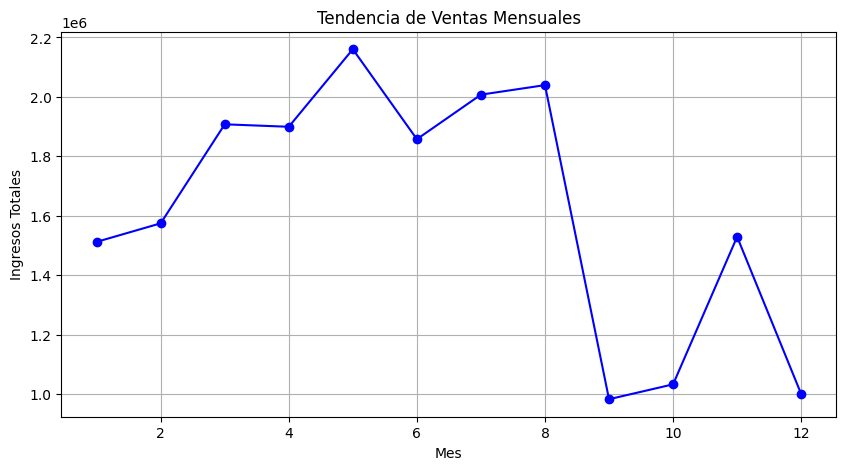

In [ ]:
# ==========================================================
# BLOQUE 3: Estacionalidad e impulso de ventas
# ==========================================================

DS_olist['mes'] = DS_olist['fecha_compra'].dt.month

# 2. Agrupamos por mes para ver los ingresos totales
ventas_mensuales = DS_olist.groupby('mes')['valor_pago_total'].sum().reset_index()

# 3. Ordenamos por mes (del 1 al 12)
ventas_mensuales = ventas_mensuales.sort_values(by='mes')

print("📅 Tendencia mensual de ingresos (Total acumulado):")
display(ventas_mensuales)

# 4.Visualización rápida para entender los picos de ventas
# Identificamos los meses de mayor demanda
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(ventas_mensuales['mes'], ventas_mensuales['valor_pago_total'], marker='o', linestyle='-', color='b')
plt.title('Tendencia de Ventas Mensuales')
plt.xlabel('Mes')
plt.ylabel('Ingresos Totales')
plt.grid(True)
plt.show()

In [38]:
# Poder adquisitivo por estado: Ticket promedio de compra
ticket_por_estado = DS_olist.groupby('estado_cliente')['valor_pago_total'].mean().sort_values(ascending=False).round(2)
print(ticket_por_estado.head(10))

estado_cliente
PB    286.04
AC    269.16
AP    259.30
RR    249.98
AL    246.53
PI    243.24
MA    239.30
MT    234.54
RO    233.75
PA    229.49
Name: valor_pago_total, dtype: float64


Conclusion: Hemos identificado una disparidad en el ticket promedio por estado. Los estados de Paraíba (PB), Acre (AC) y Amapá (AP) lideran el gasto por transacción. Esto sugiere que nuestra estrategia de marketing y oferta de productos debería tener un enfoque regional diferenciado: mayores esfuerzos de retención y propuestas de crédito en los estados de mayor ticket, y un análisis de optimización de costos en los estados con menor promedio para elevar su rentabilidad.

Bloque 5: Análisis de Similitud (Básico)
Nota: Para ver qué se parece al top, comparamos la correlación entre las categorías.

📊 Correlación entre Ticket Promedio y Volumen de Ventas:


,ticket_promedio,volumen
ticket_promedio,1.000000,-0.114176
volumen,-0.114176,1.000000


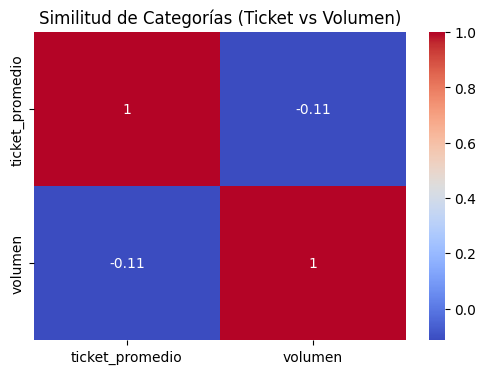

In [36]:
# ==========================================================
# BLOQUE 5: Análisis de Similitud por Comportamiento (Robusto)
# ==========================================================

# 1. Creamos una tabla con métricas clave por categoría: 
# Promedio de valor y cantidad de ventas
resumen_categorias = DS_olist.groupby('categoria_producto').agg({
    'valor_pago_total': 'mean',
    'id_item_orden': 'count'
}).rename(columns={'valor_pago_total': 'ticket_promedio', 'id_item_orden': 'volumen'})

# 2. Correlacionamos estas dos métricas
# Esto nos dirá si las categorías "caras" se venden igual que las "baratas"
correlacion_limpia = resumen_categorias.corr()

print("📊 Correlación entre Ticket Promedio y Volumen de Ventas:")
display(correlacion_limpia)

# 3. Visualización simple
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(correlacion_limpia, annot=True, cmap='coolwarm')
plt.title('Similitud de Categorías (Ticket vs Volumen)')
plt.show()

El valor -0.11 (cercano a cero) en la matriz nos está diciendo algo muy importante: No hay una relación directa entre el precio de los productos y la cantidad que se vende.

Esto se llama independencia de variables. En términos de negocio:

"Al analizar la correlación entre el ticket promedio por categoría y su volumen de ventas, encontramos un coeficiente de -0.11. Esto nos demuestra que la estrategia de ventas de Olist es saludable y diversificada: el volumen de ventas no depende exclusivamente de productos baratos ni los productos caros se venden menos necesariamente. Esto nos indica que el mercado tiene una demanda estable tanto para productos de alta gama como para productos de consumo masivo, lo que reduce el riesgo de dependencia del negocio hacia una sola categoría."